## Imports

In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc
from adam_core.time import Timestamp
from astropy.time import Time
import matplotlib.pyplot as plt
import quivr as qv
import numpy as np
import pickle
import requests
import scipy
import scipy.stats
from typing import Dict, Tuple
from adam_core.constants import DE44X_CONSTANTS

## Type Definitions

In [2]:
class RotationalPeriodInput(qv.Table):
    """Per-observation inputs for rotational period analysis:
    heliocentric and topocentric distances and phase angle from Horizons."""
    object_id = qv.LargeStringColumn()
    obs_time = Timestamp.as_column()
    sun_range = qv.Float64Column()   # heliocentric distance r [AU]
    obs_range = qv.Float64Column()   # topocentric distance Δ [AU]
    angle = qv.Float64Column()       # Sun-Target-Observer phase angle α [deg]

In [3]:
class FourierFitResult(qv.Table):
    """One row per Fourier order k (2–6) tried by run_fourier.
    Stores the best-fit frequency and residual found for that k."""
    k = qv.Int64Column(nullable=True)             # Fourier order
    sigma2 = qv.Float64Column(nullable=True)      # best weighted residual (minimized over freq grid)
    freq = qv.Float64Column(nullable=True)        # best frequency [cycles/day]; period_h = 24/freq
    n_included = qv.Int64Column(nullable=True)    # observations retained after outlier rejection
    # Fit coefficients [c1, c2, A1, B1, ..., Ak, Bk, H_g, H_i, H_r, H_u], length = 2+2k+4
    values = qv.LargeListColumn(pa.float64(), nullable=True)

In [4]:
class FourierFullResult(qv.Table):
    """Complete output of Fourier fit"""
    object_id = qv.LargeStringColumn()
    num_obs = qv.Int64Column(nullable=True)
    arc_days = qv.Float64Column(nullable=True)
    intermediate_result = qv.BinaryColumn(nullable = True) # Multiple rows of FourierFitResult
    selected_k = qv.Int64Column(nullable=True)
    count_local_maxima = qv.Int64Column(nullable=True)
    period_h = qv.Float64Column(nullable=True)
    amplitude = qv.Float64Column(nullable=True)
    color_gr = qv.Float64Column(nullable=True)
    color_gi = qv.Float64Column(nullable=True)
    color_ri = qv.Float64Column(nullable=True)
    elongation = qv.Float64Column(nullable=True)

In [5]:
class PaperTable2(qv.Table):
    """Table 2 from Greenstreet et al. 2026 (ApJL 996 L33).
    Reference results for 78 near-Earth asteroids: periods, amplitudes, colors."""
    designation = qv.LargeStringColumn()
    h_mag = qv.Float64Column()
    mean_mag_r = qv.Float64Column()
    num_observations = qv.Int64Column()
    arc_days = qv.Int64Column()
    period_lsm = qv.Float64Column()      # [h]
    period_fourier = qv.Float64Column()  # [h]
    amplitude_lsm = qv.Float64Column()
    amplitude_fourier = qv.Float64Column()
    g_minus_r_lsm = qv.Float64Column()
    g_minus_r_fourier = qv.Float64Column()
    g_minus_i_lsm = qv.Float64Column()
    g_minus_i_fourier = qv.Float64Column()
    r_minus_i_lsm = qv.Float64Column()
    r_minus_i_fourier = qv.Float64Column()
    axial_elongation = qv.Float64Column()


_designation = [
    "2025 MA19", "2025 MA45", "2025 MA46", "2025 MC34", "2025 MD38",
    "2025 MD40", "2025 MD67", "2025 MD76", "2025 ME15", "2025 ME24",
    "2025 ME68", "2025 MF76", "2025 MG17", "2025 MG56", "2025 MH40",
    "2025 MH69", "2025 MH75", "2025 MH86", "2025 MJ13", "2025 MJ21",
    "2025 MJ23", "2025 MJ30", "2025 MJ71", "2025 MJ79", "2025 MK23",
    "2025 MK41", "2025 MK68", "2025 MK83", "2025 MK88",
    "2025 ML10", "2025 ML17", "2025 ML35", "2025 ML52", "2025 ML53",
    "2025 MM37", "2025 MM81", "2025 MM82", "2025 MN25", "2025 MN37",
    "2025 MN45", "2025 MN7",  "2025 MO35", "2025 MO39", "2025 MO47",
    "2025 MO79", "2025 MP21", "2025 MP47", "2025 MP61", "2025 MP67",
    "2025 MP71", "2025 MQ58", "2025 MR33", "2025 MS34", "2025 MS7",
    "2025 MT24", "2025 MU10", "2025 MU15", "2025 MU24",
    "2025 MU59", "2025 MU8",  "2025 MU9",  "2025 MV19", "2025 MV31",
    "2025 MV38", "2025 MV4",  "2025 MV46", "2025 MV71", "2025 MW70",
    "2025 MX34", "2025 MX44", "2025 MX50", "2025 MX63", "2025 MX69",
    "2025 MY23", "2025 MY77", "2025 MZ78",
]
_h_mag = [
    18.1, 19.5, 18.1, 18.5, 18.0, 19.0, 18.1, 18.3, 19.8, 18.4,
    21.2, 18.9, 17.1, 18.9, 19.1, 19.1, 19.0, 18.2, 20.9, 18.8,
    17.9, 18.0, 22.70, 20.0, 20.4, 19.3, 19.1, 20.1, 18.4,
    18.3, 18.5, 19.4, 18.8, 18.4, 19.6, 21.1, 19.0, 20.5, 17.8,
    18.7, 18.1, 18.4, 19.3, 18.5, 20.1, 17.9, 18.8, 18.4, 19.0,
    18.3, 18.4, 18.3, 18.3, 18.5, 17.8, 20.6, 21.6, 18.7,
    19.0, 19.0, 18.4, 18.0, 18.8, 17.9, 19.6, 17.8, 18.2, 18.5,
    19.4, 17.9, 19.8, 19.1, 19.2, 18.9, 18.1, 17.8,
]
_mean_mag_r = [
    22.66, 22.50, 23.13, 23.02, 22.80, 23.35, 22.36, 23.02, 22.95, 23.32,
    23.51, 21.82, 22.76, 22.86, 22.56, 23.12, 22.67, 23.00, 23.06, 22.22,
    22.69, 22.82, 23.44, 23.92, 22.58, 22.17, 22.16, 22.77, 23.19,
    23.20, 23.28, 23.10, 22.91, 22.83, 22.40, 22.90, 22.96, 22.95, 22.20,
    22.24, 23.00, 22.37, 22.84, 23.43, 23.27, 22.67, 22.73, 23.51, 22.75,
    22.23, 23.11, 22.40, 23.05, 23.04, 22.15, 22.32, 23.53, 22.79,
    22.00, 23.22, 22.72, 22.60, 22.98, 22.91, 23.36, 22.47, 22.74, 22.45,
    22.37, 23.21, 22.14, 23.22, 22.51, 22.10, 22.51, 23.21,
]
_num_observations = [
    447, 140, 291, 321, 458, 393, 232, 404, 329, 386,
    192, 244, 289, 213, 379, 314, 399, 456, 116, 262,
    121, 291, 272, 70, 112, 426, 147, 333, 234,
    294, 255, 411, 436, 121, 305, 390, 412, 318, 424,
    517, 347, 417, 141, 279, 122, 314, 398, 268, 194,
    359, 314, 490, 292, 114, 408, 450, 182, 475,
    503, 276, 324, 254, 277, 241, 350, 502, 334, 265,
    174, 488, 432, 327, 213, 199, 258, 167,
]
_arc_days = [
    9, 12, 12, 12, 12, 12, 2, 12, 12, 12,
    12, 6, 6, 12, 9, 12, 12, 12, 12, 4,
    2, 12, 6, 6, 12, 12, 2, 12, 12,
    6, 12, 12, 12, 12, 9, 9, 12, 12, 9,
    12, 12, 12, 2, 12, 9, 12, 12, 9, 4,
    12, 12, 12, 6, 2, 9, 6, 12, 6,
    12, 12, 6, 6, 6, 6, 12, 12, 12, 12,
    2, 12, 12, 9, 4, 12, 6, 4,
]
_period_lsm = [
    8.9, 1.6, 5.9, 8.4, 15.8, 4.4, 7.8, 11.0, 6.9, 2.9,
    0.9, 2.2, 4.3, 0.3, 8.0, 6.7, 4.2, 4.4, 3.4, 3.4,
    7.4, 5.6, 0.031, 1.0, 6.2, 0.063, 5.0, 6.1, 2.7,
    7.0, 6.7, 21.3, 11.5, 5.2, 3.7, 1.1, 5.0, 0.4, 4.8,
    0.031, 6.8, 6.3, 4.9, 9.1, 5.5, 6.2, 4.9, 3.0, 4.1,
    9.1, 2.9, 3.5, 2.3, 4.6, 8.9, 6.5, 0.4, 2.2,
    8.2, 0.8, 4.9, 7.4, 5.2, 6.0, 5.9, 3.4, 0.2, 3.9,
    5.8, 1.1, 1.9, 8.3, 9.1, 3.1, 7.6, 1.2,
]
_period_fourier = [
    8.9, 1.6, 5.9, 8.4, 9.5, 4.4, 3.3, 11.0, 8.1, 4.2,
    0.9, 2.0, 4.3, 0.3, 6.9, 7.8, 4.2, 4.4, 3.1, 3.9,
    5.2, 5.6, 0.031, 0.4, 10.6, 0.063, 5.0, 6.1, 2.5,
    7.0, 6.7, 21.3, 9.2, 7.0, 1.9, 1.1, 5.0, 0.4, 6.8,
    0.031, 10.6, 6.3, 6.2, 9.1, 2.7, 5.5, 2.2, 5.6, 6.2,
    9.1, 3.1, 3.5, 2.3, 4.6, 8.9, 6.5, 0.4, 2.2,
    8.2, 0.8, 3.5, 7.4, 5.8, 6.0, 5.3, 3.4, 0.2, 3.9,
    4.7, 1.2, 1.9, 8.3, 7.7, 3.1, 7.6, 1.2,
]
_amplitude_lsm = [
    0.7, 0.7, 0.6, 0.8, 1.1, 0.7, 1.2, 0.7, 0.9, 0.3,
    0.6, 0.2, 0.4, 0.5, 1.4, 0.7, 0.5, 0.5, 0.6, 0.3,
    0.8, 0.5, 0.4, 0.2, 0.9, 0.2, 0.7, 0.5, 0.4,
    1.0, 0.6, 0.8, 0.7, 0.7, 0.3, 1.0, 0.8, 0.4, 0.8,
    0.4, 0.7, 0.5, 0.9, 0.7, 0.6, 0.6, 0.4, 0.6, 0.7,
    0.4, 0.3, 0.3, 0.5, 0.8, 1.0, 0.5, 0.5, 0.3,
    0.6, 0.6, 0.6, 0.7, 0.7, 0.6, 0.8, 0.2, 0.4, 0.2,
    0.7, 0.2, 0.3, 0.7, 0.7, 0.2, 1.0, 0.5,
]
_amplitude_fourier = [
    1.0, 0.6, 0.6, 0.9, 1.1, 0.7, 0.5, 0.6, 0.9, 0.4,
    0.5, 0.1, 0.4, 0.8, 0.7, 0.7, 0.4, 0.5, 0.9, 0.3,
    0.9, 0.5, 0.4, 0.2, 1.7, 0.3, 0.6, 0.5, 0.4,
    1.1, 0.6, 1.0, 0.7, 0.8, 0.3, 1.2, 0.9, 0.4, 0.9,
    0.4, 0.7, 0.5, 1.0, 0.7, 0.6, 0.5, 0.3, 0.7, 0.7,
    0.4, 0.4, 0.2, 0.5, 0.7, 1.1, 0.5, 0.5, 0.2,
    0.6, 0.6, 0.7, 0.7, 0.6, 0.6, 0.6, 0.1, 0.6, 0.3,
    0.8, 0.3, 0.3, 0.5, 1.3, 0.2, 1.1, 0.5,
]
_g_minus_r_lsm = [
    0.44, 0.35, 0.53, 0.52, 0.46, 0.45, 0.50, 0.46, 0.61, 0.51,
    0.59, 0.56, 0.46, 0.47, 0.47, 0.63, 0.58, 0.44, 0.46, 0.43,
    0.64, 0.50, 0.58, 0.47, 0.65, 0.41, 0.50, 0.58, 0.60,
    0.50, 0.37, 0.54, 0.54, 0.38, 0.52, 0.55, 0.73, 0.42, 0.56,
    0.43, 0.47, 0.57, 0.46, 0.44, 0.57, 0.52, 0.43, 0.49, 0.63,
    0.57, 0.60, 0.68, 0.59, 0.49, 0.63, 0.52, 0.50, 0.66,
    0.54, 0.47, 0.48, 0.46, 0.43, 0.68, 0.47, 0.55, 0.44, 0.63,
    0.67, 0.41, 0.64, 0.60, 0.52, 0.57, 0.60, 0.46,
]
_g_minus_r_fourier = [
    0.46, 0.45, 0.53, 0.49, 0.46, 0.44, 0.51, 0.49, 0.63, 0.51,
    0.58, 0.58, 0.46, 0.48, 0.43, 0.63, 0.58, 0.44, 0.32, 0.40,
    0.56, 0.50, 0.58, 0.42, 0.56, 0.40, 0.63, 0.55, 0.62,
    0.54, 0.40, 0.58, 0.55, 0.42, 0.48, 0.53, 0.74, 0.41, 0.54,
    0.42, 0.47, 0.56, 0.37, 0.43, 0.62, 0.54, 0.47, 0.55, 0.62,
    0.57, 0.65, 0.66, 0.58, 0.47, 0.49, 0.52, 0.48, 0.64,
    0.58, 0.46, 0.47, 0.46, 0.54, 0.68, 0.48, 0.52, 0.43, 0.62,
    0.63, 0.42, 0.63, 0.59, 0.49, 0.58, 0.61, 0.46,
]
_g_minus_i_lsm = [
    0.49, 0.65, 0.71, 0.69, 0.54, 0.59, 0.72, 0.65, 0.78, 0.70,
    0.75, 0.75, 0.59, 0.59, 0.58, 0.81, 0.82, 0.54, 0.48, 0.49,
    0.71, 0.67, 0.78, 0.65, 0.63, 0.55, 0.58, 0.73, 0.80,
    0.57, 0.48, 0.78, 0.67, 0.63, 0.58, 0.67, 0.88, 0.51, 0.73,
    0.56, 0.62, 0.71, 0.47, 0.72, 0.69, 0.65, 0.48, 0.70, 0.79,
    0.83, 0.78, 0.83, 0.74, 0.58, 0.64, 0.67, 0.69, 0.80,
    0.79, 0.58, 0.61, 0.68, 0.71, 0.86, 0.58, 0.70, 0.57, 0.90,
    0.91, 0.56, 0.81, 0.80, 0.53, 0.72, 0.80, 0.58,
]
_g_minus_i_fourier = [
    0.55, 0.60, 0.68, 0.70, 0.59, 0.58, 0.59, 0.65, 0.79, 0.70,
    0.76, 0.75, 0.58, 0.59, 0.55, 0.93, 0.83, 0.53, 0.82, 0.50,
    0.767, 0.68, 0.76, 0.71, 0.77, 0.56, 0.81, 0.67, 0.84,
    0.64, 0.49, 0.82, 0.75, 0.64, 0.59, 0.66, 0.83, 0.54, 0.75,
    0.57, 0.59, 0.71, 0.44, 0.74, 0.71, 0.72, 0.62, 0.70, 0.83,
    0.78, 0.74, 0.87, 0.75, 0.56, 0.62, 0.66, 0.69, 0.80,
    0.77, 0.58, 0.57, 0.66, 0.67, 0.91, 0.64, 0.67, 0.57, 0.90,
    0.83, 0.54, 0.83, 0.79, 0.56, 0.72, 0.91, 0.60,
]
_r_minus_i_lsm = [
    0.05, 0.30, 0.18, 0.16, 0.08, 0.14, 0.21, 0.18, 0.17, 0.19,
    0.16, 0.19, 0.13, 0.12, 0.11, 0.18, 0.23, 0.10, 0.02, 0.06,
    0.06, 0.16, 0.20, 0.18, -0.02, 0.14, 0.08, 0.14, 0.20,
    0.07, 0.10, 0.24, 0.13, 0.25, 0.06, 0.12, 0.15, 0.08, 0.18,
    0.13, 0.15, 0.14, 0.01, 0.28, 0.12, 0.13, 0.04, 0.21, 0.16,
    0.25, 0.18, 0.15, 0.15, 0.09, 0.01, 0.15, 0.19, 0.13,
    0.25, 0.12, 0.13, 0.23, 0.27, 0.18, 0.11, 0.15, 0.13, 0.28,
    0.23, 0.16, 0.17, 0.20, 0.01, 0.15, 0.20, 0.12,
]
_r_minus_i_fourier = [
    0.08, 0.14, 0.15, 0.21, 0.13, 0.14, 0.07, 0.16, 0.16, 0.19,
    0.18, 0.17, 0.13, 0.11, 0.12, 0.30, 0.24, 0.09, 0.50, 0.10,
    0.21, 0.17, 0.18, 0.3, 0.2, 0.16, 0.18, 0.12, 0.22,
    0.10, 0.10, 0.24, 0.20, 0.21, 0.11, 0.12, 0.09, 0.13, 0.21,
    0.14, 0.12, 0.15, 0.07, 0.31, 0.09, 0.17, 0.15, 0.15, 0.21,
    0.20, 0.10, 0.21, 0.17, 0.08, 0.13, 0.14, 0.21, 0.16,
    0.20, 0.12, 0.10, 0.20, 0.13, 0.23, 0.16, 0.15, 0.13, 0.28,
    0.20, 0.12, 0.20, 0.20, 0.06, 0.14, 0.30, 0.14,
]
_axial_elongation = [
    2.1, 1.5, 1.6, 1.9, 2.2, 1.7, 1.4, 1.6, 1.9, 1.3,
    1.4, 1.1, 1.3, 1.7, 1.7, 1.7, 1.3, 1.5, 1.8, 1.2,
    2.0, 1.4, 1.3, 1.2, 3.1, 1.2, 1.5, 1.4, 1.4,
    2.2, 1.5, 2.0, 1.7, 1.8, 1.2, 2.1, 1.9, 1.3, 2.0,
    1.3, 1.7, 1.4, 1.9, 1.7, 1.6, 1.5, 1.2, 1.7, 1.6,
    1.4, 1.3, 1.2, 1.4, 1.7, 2.2, 1.3, 1.4, 1.2,
    1.5, 1.5, 1.7, 1.7, 1.6, 1.6, 1.5, 1.1, 1.6, 1.2,
    1.7, 1.3, 1.2, 1.4, 2.4, 1.1, 2.2, 1.5,
]

paper_table2 = PaperTable2.from_kwargs(
    designation=_designation,
    h_mag=_h_mag,
    mean_mag_r=_mean_mag_r,
    num_observations=_num_observations,
    arc_days=_arc_days,
    period_lsm=_period_lsm,
    period_fourier=_period_fourier,
    amplitude_lsm=_amplitude_lsm,
    amplitude_fourier=_amplitude_fourier,
    g_minus_r_lsm=_g_minus_r_lsm,
    g_minus_r_fourier=_g_minus_r_fourier,
    g_minus_i_lsm=_g_minus_i_lsm,
    g_minus_i_fourier=_g_minus_i_fourier,
    r_minus_i_lsm=_r_minus_i_lsm,
    r_minus_i_fourier=_r_minus_i_fourier,
    axial_elongation=_axial_elongation,
)

## Data pull from New Horizons

In [6]:
def _parse_rotational_period_input_response(object_id: str, text: str) -> RotationalPeriodInput:
    lines = text.splitlines()
    row = 0
    while row < len(lines) and not lines[row].startswith("$$SOE"):
        row += 1
    row += 1
    jd = []
    sun_range = []
    obs_range = []
    angle = []
    while row < len(lines) and not lines[row].startswith("$$EOE"):
        parts = lines[row].split(",")
        # text date, JD data, solar presence, lunar presence, sun range to target AU,
        # observer range to target AU, Sun-Target-Observer angle degrees, <-- extra comma
        assert len(parts) >= 7, f"Actual length {len(parts)}: {parts}"
        jd.append(float(parts[1]))
        sun_range.append(float(parts[4]))
        obs_range.append(float(parts[5]))
        angle.append(float(parts[6]))
        row += 1
    return RotationalPeriodInput.from_kwargs(
        object_id = [object_id] * len(jd),
        obs_time = Timestamp.from_jd(jd),
        sun_range = sun_range,
        obs_range = obs_range,
        angle = angle,
    )


def _query_rotational_period_inputs(object_id: str, stn: str, obs_times: pa.DoubleArray) -> RotationalPeriodInput:
    API_URL = "https://ssd.jpl.nasa.gov/api/horizons.api"
    chunk_size = 30 # 100 is too much
    start_chunk = 0
    sess = requests.Session() # TODO: parallel queries?
    # Selected: 
    # "19: heliocentric range and range rate"
    # "20: observer range and range rate"
    # "24: Sun-target-observer ~PHASE angle"
    # Suppress rates, only use ranges
    params = {
        "format": "text",
        "COMMAND": f"'DES={object_id};'",
        "OBJ_DATA": "NO", # default YES
        # "MAKE_EPHEM": "YES", # default
        #"EPHEM_TYPE": "OBSERVER", # default
        "CENTER": stn,
        "TIME_TYPE": "UT",
        "TLIST_TYPE": "MJD",
        "QUANTITIES": "'19,20,24'",
        "CAL_FORMAT": "BOTH", # CAL & JD
        "CSV_FORMAT": "YES",
        # "RANGE_UNITS": "AU", # default
        "SUPPRESS_RANGE_RATE": "YES", # default NO
    }
    collections = []
    while start_chunk < len(obs_times):
        tlist = [f"'{v}'" for v in obs_times[start_chunk:start_chunk+chunk_size]]
        start_chunk += chunk_size
        params["TLIST"] = " ".join(tlist)
        resp = sess.get(
            API_URL, params=params, timeout=10
        )
        resp.raise_for_status()
        collections.append(_parse_rotational_period_input_response(object_id, resp.text))
    return qv.concatenate(collections)

def cache_or_query_rotational_period_inputs(object_id: str,
                                            stn: str,
                                            obs_times: pa.DoubleArray,
                                            cache_file: str = "../data/rot_period_inputs.parquet",
                                            force_query: bool = False) -> RotationalPeriodInput:
    
    try:
        input_data = RotationalPeriodInput.from_parquet(cache_file)
        print(f"Read total {len(input_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        input_data = RotationalPeriodInput.empty()
    result = input_data.apply_mask(pc.equal(input_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Query API for {object_id} and {len(obs_times)} timestamps")
        result = _query_rotational_period_inputs(object_id, stn, obs_times)
        input_data = qv.concatenate([
            input_data.apply_mask(pc.not_equal(input_data.object_id, object_id)),
            result,
            ])
        input_data.to_parquet(cache_file)
    return result


## Read pre-pulled data for observations

In [7]:
all_data = pq.read_table("../data/paper_data.parquet")
all_data = all_data.sort_by("obstime")

In [8]:
def subset_data(object_id: str, data: pa.Table) -> Tuple[pa.Table, pa.DoubleArray, Dict[str, pa.DoubleArray], Dict[str, pa.DoubleArray]]:
    """Pulls data for the given object from the collection of all data
    
    Returns:
    --------
    obs_time: DoubleArray
      All observation times for the given object as MJD, sorted ascending
    otime: dict[str, Timestamp]
      Dictionary from band color to timestamps for it
    mag: dict[str, DoubleArray]
      Dictionary from band color to magnitudes for it
    """
    selection = data.filter(pc.equal(data["provid"], object_id))
    obs_time = Timestamp.from_astropy(Time(selection["obstime"].to_pylist())).mjd()
    arc_len = pc.max(obs_time).as_py() - pc.min(obs_time).as_py()
    mag = {}
    otime = {}
    # TODO: And see other 'spellings' of same 4 colors
    for color in ["g", "i", "r", "u"]:
        color_lines = selection.filter(pc.equal(selection["band"], color))
        if len(color_lines) > 0:
          mag[color] = color_lines["mag"].cast('float')
          otime[color] = Timestamp.from_astropy(Time(color_lines["obstime"]))
    mean_mag_r = pc.mean(mag["r"])
    delta_mag_r = pc.max(mag["r"]).as_py() - pc.min(mag["r"]).as_py()
    print(f"For object {object_id}: num obs {len(selection)}, arc length {arc_len}")
    print(f"Mean mag in r-band {mean_mag_r}, delta mag in r-band {delta_mag_r}")
    print(f"Counts per band: g {len(mag['g'])}, i {len(mag['i'])}, r {len(mag['r'])}, u {len(mag.get('u', []))}")
    assert np.sum([len(v) for v in mag.values()]) == len(selection), f"Add missing colors, object {object_id}: {pc.unique(selection['band'])}"
    return selection, obs_time, otime, mag

## Sanity check for the data
Repro Figure 8 from the paper to see if our data input makes sense

In [9]:
# Pick an object from the paper "2025 MM81"
# should have mag variation 1.2, period 0.045 days ~= 1.1h
# from page 11 of the paper for 2025MM81:
# H mag = 21.1, mean mag r-band = 22.90, num obs=390, arc (days) 9,
# period (LSM/Furier) 1.1/1.1,
# Amplitude LSM/Furier 1.0/1.2, g-r LSM/Furier 0.55/0.53, g-i LSM/Furier 0.67/0.66,
# r-i LSM/Furier 0.12/0.12, axial elongation 2.1
mm81_id = "2025 MM81"
mm81_selection, mm81_obstime, mm81_otime, mm81_mag = subset_data(mm81_id, all_data)

For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174, u 0


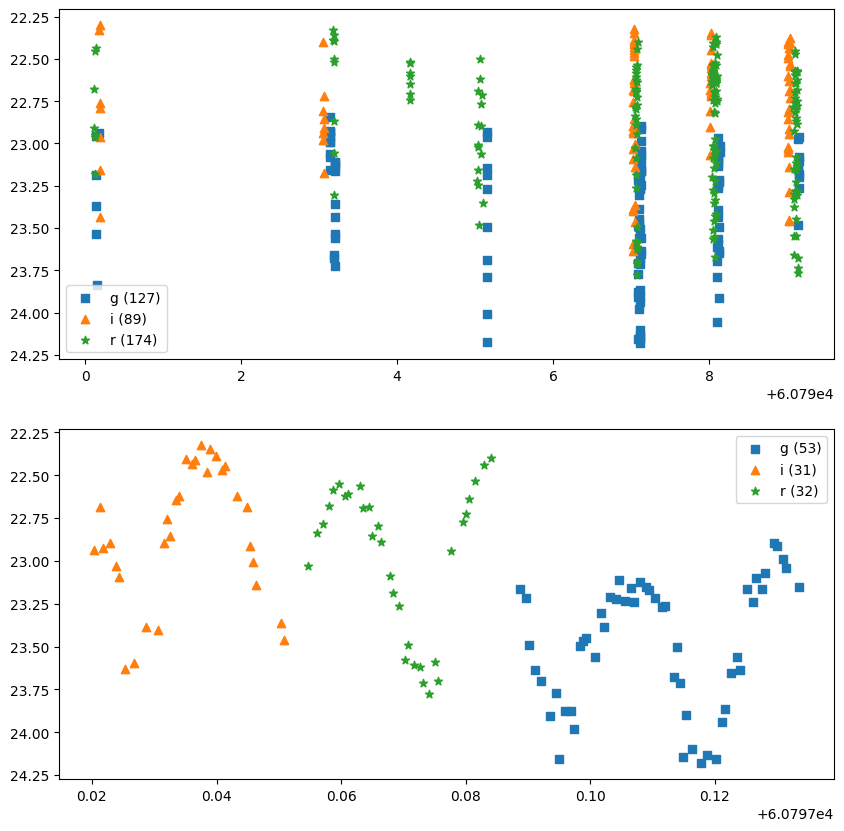

In [10]:
# Repro Figure 8 from the paper
def show_figure8(obs_time, otime, mag, first_day: float):
    """Draw figure similar to Figure8 in the paper.
    Parameters:
    -----------
    obs_time:
      sorted list of all observation times for the given object

    """
    # print(pc.min(otime["g"].mjd()), pc.max(otime["g"].mjd()))
    _fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    axs[0].scatter(otime["g"].mjd().to_pylist(), mag["g"].to_pylist(), marker="s", c="tab:blue", label=f"g ({len(mag['g'])})")
    axs[0].scatter(otime["i"].mjd().to_pylist(), mag["i"].to_pylist(), marker="^", c="tab:orange", label=f"i ({len(mag['i'])})")
    axs[0].scatter(otime["r"].mjd().to_pylist(), mag["r"].to_pylist(), marker="*", c="tab:green", label=f"r ({len(mag['r'])})")
    axs[0].legend()
    axs[0].invert_yaxis()

    # Find the night with the observation count matching Figure 8 in the paper
    beginning_of_time = pc.min(obs_time).as_py() - 0.25
    start_time = beginning_of_time + first_day # 6 is the number that matched the count
    end_time = start_time + 1.5 # make sure to get the whole night

    selected_times = {}
    selected_mags = {}
    for color in ["g", "i", "r"]:
        index = pc.and_(pc.greater(otime[color].mjd(), start_time), pc.less(otime[color].mjd(), end_time))
        selected_times[color] = otime[color].mjd().to_numpy()[index]
        selected_mags[color] = mag[color].to_numpy()[index]
    axs[1].scatter(selected_times["g"], selected_mags["g"], marker="s", c="tab:blue", label=f"g ({len(selected_mags['g'])})")
    axs[1].scatter(selected_times["i"], selected_mags["i"], marker="^", c="tab:orange", label=f"i ({len(selected_mags['i'])})")
    axs[1].scatter(selected_times["r"], selected_mags["r"], marker="*", c="tab:green", label=f"r ({len(selected_mags['r'])})")
    axs[1].legend()
    axs[1].invert_yaxis()

    plt.show()

show_figure8(mm81_obstime, mm81_otime, mm81_mag, 6)

## High-order Fourier Analysis

In [11]:
def _adjust_inputs_for_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput,
                              obs_time: pa.DoubleArray) -> Tuple[np.ndarray, np.ndarray]:
    """Correct observations for the light time and distance.
    Returns corrected observed times and magnitudes in the original order."""
    # Sanity that the arrays are sorted, so we can just match indexes
    deltas = pc.subtract(obs_time, range_inputs.obs_time.mjd())
    assert pc.max(pc.abs(deltas)).as_py() < 1e-9

    observed_mags = np.array([float(v) for v in observation_table["mag"]])
    helio_r = range_inputs.sun_range.to_numpy()
    topo_delta = range_inputs.obs_range.to_numpy()
    alpha = range_inputs.angle.to_numpy()
    print(f"Alpha range {np.min(alpha)} - {np.max(alpha)}")

    # Page 6, section 3.1
    # Subtract 5*log10(r*delta) from observational magnitudes
    # print(f"Sizes V={observed_mags.shape}, r={helio_r.shape}, delta={topo_delta.shape}, alpha={alpha.shape}")
    observed_mags = observed_mags - 5*np.log10(helio_r * topo_delta)

    # Correct timing for speed of light: t = t_obs - delta/c
    observed_time = obs_time - topo_delta / DE44X_CONSTANTS["C"]
    return observed_time, observed_mags

def _get_freqs(fmin: float, fmax: float, arc_len: float) -> np.ndarray:
    """Returns the list of frequencies to try in Fourier analysis."""
    N = int(30 * arc_len * (fmax - fmin))
    return np.linspace(fmin, fmax, num=N)

In [12]:
def _fit_fourier(freq: float, k: int, obs_v, obs_t, alpha, bands, weights) -> Tuple[np.ndarray, float, int]:
    # return values, sigma2, np.sum(included)

    # Model phi(alpha) = c1*alpha + c2*alpha^2
    # g (t ) = sum(j=1:k) Aj*cos (2 fjt ) + Bj*sin (2 fjt ) for k 2:6
    # X=[c1, c2, A1, B1, ..., Ak, Bk, Hg, Hi, Hr, Hu ], B == obs_v
    num_params = 2 + 2*k + 4
    num_obs = len(obs_v)
    A = np.zeros((num_obs, num_params))

    A[:, 0] = alpha # *c1
    A[:, 1] = alpha*alpha # *c2
    # Fourier coeffs
    base = 2*np.pi*freq*obs_t
    idx = 2
    for j in range(1, k+1):
        arg = base * j
        A[:, idx] = np.cos(arg)
        A[:, idx+1] = np.sin(arg)
        idx+=2
    # Pick color
    color_offset = {'g': 0, 'i': 1, 'r': 2, 'u': 3}
    for i in range(num_obs):
        color = bands[i].as_py()
        try:
            A[i, idx+color_offset[color]] = 1
        except KeyError:
            raise BaseException(f"Bad color [{color}] index {i}")
    # Build weighted matrices
    W = np.diag(np.sqrt(weights))
    Aw = np.dot(W, A)
    Bw = np.dot(obs_v, W)

    # May need to throw away outliers
    converged = False
    included = np.array([True] * num_obs)
    while not converged:
        values, _residuals, rank, singulars = np.linalg.lstsq(Aw[included, :], Bw[included])
        # if 'u' color is not present, rank would be num_params-1
        # assert rank == num_params
        # assert len(singulars) == rank

        # Compute p_j*(Oj-Cj)^2
        res = (obs_v - A @ values)**2 * weights # this includes already rejected, it's okay
        n_incl = np.sum(included)
        sigma2 = np.sum(res[included]) / (n_incl - num_params) # discard rejected here
        outliers = res > 9*sigma2 # not masking here, because included accumulates
        # Converged if there are no NEW outliers
        converged = np.sum(outliers[included]) == 0
        included = included & ~outliers

    return values, num_obs * sigma2 / np.sum(weights), np.sum(included)


def run_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput, obs_time: pa.DoubleArray,
                min_freq: float = 0.1667, max_freq: float = 500) -> Tuple[FourierFitResult, float]:
    observed_time, observed_mags = _adjust_inputs_for_fourier(observation_table, range_inputs, obs_time)
    arc_length = np.max(obs_time) - np.min(obs_time)
    freqs = _get_freqs(min_freq, max_freq, arc_length)
    print(f"Freqs count {freqs.shape}, arc length={arc_length}")

    alpha = np.deg2rad(range_inputs.angle.to_numpy())
    weights = 1 / (np.array([float(w) for w in observation_table["rmsmag"]]) ** 2)

    # Page 7: for each k, find freq that gives minimum sigma2 for that k
    rows_k, rows_sigma2, rows_freq, rows_n_included, rows_values = [], [], [], [], []
    for k in range(2, 7):
        best_sigma2 = np.inf
        best_fit = None
        best_freq = np.inf
        best_size = np.inf
        for f in freqs:
            X, sigma2, n_incl = _fit_fourier(f, k, observed_mags, observed_time, alpha, observation_table["band"], weights)
            if sigma2 < best_sigma2:
                best_sigma2 = sigma2
                best_fit = X
                best_freq = f
                best_size = n_incl
        print(f"For k={k} got best freq {best_freq} with sigma={best_sigma2} H={best_fit[-4:]} N={best_size} -> period = {24.0 / best_freq} h")
        rows_k.append(k)
        rows_sigma2.append(best_sigma2)
        rows_freq.append(best_freq)
        rows_n_included.append(int(best_size))
        rows_values.append(best_fit.tolist())

    return FourierFitResult.from_kwargs(
        k=rows_k,
        sigma2=rows_sigma2,
        freq=rows_freq,
        n_included=rows_n_included,
        values=rows_values,
    ), arc_length

In [13]:
def best_row_by_f(fourier_result: FourierFitResult, alpha: float=0.05) -> FourierFitResult:
    """Select the best Fourier order k using an F-test.
    Returns the single winning row as a FourierFitResult."""
    best_row = 0
    best_row_changed = True
    while best_row_changed:
        best_row_changed = False
        k_i      = fourier_result.k[best_row].as_py()
        sigma2_i = fourier_result.sigma2[best_row].as_py()
        size_i   = fourier_result.n_included[best_row].as_py()
        for j in range(best_row + 1, len(fourier_result)):
            k_j      = fourier_result.k[j].as_py()
            sigma2_j = fourier_result.sigma2[j].as_py()
            size_j   = fourier_result.n_included[j].as_py()
            F = sigma2_i / sigma2_j
            p = 1 - scipy.stats.f.cdf(F, size_i - 1, size_j - 1)
            print(f"K={k_i},{k_j} sigmas2={sigma2_i},{sigma2_j} F={F}, p={p}")
            if p < alpha and sigma2_j < sigma2_i:
                print(f"Switch best row to {j}")
                best_row = j
                best_row_changed = True
                break
    best = fourier_result.take([best_row])
    print(f"Best row={best_row} for k={best.k[0].as_py()}")
    return best


def amplitude(fit: FourierFitResult, alpha_avg: float) -> Tuple[float, float, float, float, float, int]:
    """Compute amplitude, colors, and elongation from the best-fit Fourier row.

    Parameters
    ----------
    fit : single-row FourierFitResult (the winner from best_row_by_f)
    alpha_avg : mean phase angle [radians]

    Returns
    -------
    ampl, color_gr, color_gi, color_ri, elongation, count_local_maxima
    """
    k      = fit.k[0].as_py()
    freq   = fit.freq[0].as_py()
    values = fit.values[0].as_py()  # [c1, c2, A1, B1, ..., Ak, Bk, H_g, H_i, H_r]

    period_days = 1 / freq
    sample = np.linspace(0, 2*period_days, num=1000)
    base = 2*np.pi*freq*sample
    G = np.zeros(len(sample))
    assert len(values) == 2 + k*2 + 4
    for j in range(k):
        arg = base * (j + 1)
        G += values[2+2*j]   * np.cos(arg)
        G += values[2+2*j+1] * np.sin(arg)
    ampl = np.max(G) - np.min(G)

    max_count = sum(1 for i in range(1, len(G)-1) if G[i-1] < G[i] and G[i] >= G[i+1])
    print(f"Count of local maxima {max_count}, G size {len(G)}")
    print(f"Amplitude {ampl}")

    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    assert 2+2*k+3 == len(values)-1
    print(f"Colors g-r={H_g-H_r} g-i={H_g-H_i} r-i={H_r-H_i}")

    A0 = ampl / (1 + 0.02*alpha_avg)
    elongation = 10 ** (0.4*A0)
    print(f"Elongation={elongation}")
    return ampl, H_g-H_r, H_g-H_i, H_r-H_i, elongation, max_count

In [14]:
def run_complete_fourier(object_id: str) -> FourierFullResult:
    """Run the complete Fourier rotational-period pipeline for one object.

    Returns a single-row FourierFullResult with the best-fit summary
    and the winning FourierFitResult row embedded as intermediate_result.
    """
    selection, obstime, _otime, _mag = subset_data(object_id, all_data)
    inputs = cache_or_query_rotational_period_inputs(object_id, "X05", obstime)
    print(f"All colors {selection['band'].unique().to_pylist()}")

    fit, arc_length = run_fourier(selection, inputs, obstime)
    best_fit = best_row_by_f(fit)
    ampl, color_gr, color_gi, color_ri, elongation, max_count = amplitude(
        best_fit, np.deg2rad(np.average(inputs.angle))
    )
    period_h = 24.0 / best_fit.freq[0].as_py()
    if max_count < 3:
        print(f"Double the period, count of maximums is {max_count}")
        period_h *= 2
    return FourierFullResult.from_kwargs(
        object_id=[object_id],
        num_obs = [len(obstime)],
        arc_days = [arc_length],
        intermediate_result=[pickle.dumps(fit)],
        selected_k=[best_fit.k[0].as_py()],
        count_local_maxima=[max_count],
        period_h=[period_h],
        amplitude=[ampl],
        color_gr=[color_gr],
        color_gi=[color_gi],
        color_ri=[color_ri],
        elongation=[elongation],
    )

In [15]:
def run_complete_fourier_with_cache(object_id: str, 
                                    cache_file: str = "../data/fourier_outputs.parquet",
                                    force_query: bool = False) -> FourierFullResult:
    try:
        output_data = FourierFullResult.from_parquet(cache_file)
        print(f"Read total {len(output_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        output_data = FourierFullResult.empty()
    result = output_data.apply_mask(pc.equal(output_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Recomputing Fourier for object {object_id}")
        result = run_complete_fourier(object_id)
        output_data = qv.concatenate([
            output_data.apply_mask(pc.not_equal(output_data.object_id, object_id)),
            result,
            ])
        output_data.to_parquet(cache_file)
    return result
   

## Viz functions that may be occasionally helpful

In [16]:
def viz_vs_data(id, day, inputs, id_fit):
    k, sigma2, freq, values, size = id_fit
    fig, ax = plt.subplots(1,1, figsize=(10, 5))
    id_selection, id_obstime, id_otime, id_mag = subset_data(id, all_data)
    id_obstime = id_obstime.to_numpy()
    mag = id_selection["mag"].cast('float').to_numpy()
    start_time = np.min(id_obstime) - 0.25
    if day is not None:
        start_time += day
        index = (id_obstime > start_time) & (id_obstime < (start_time+1))
    else:
        index = np.array([True] * len(id_obstime))

    alpha = np.deg2rad(inputs.angle)[0]
    alpha_corr = values[0]*alpha + values[1]*alpha*alpha
    helio_r = inputs.sun_range.to_numpy()[0]
    topo_delta = inputs.obs_range.to_numpy()[0]
    mag_corr = 5*np.log10(helio_r * topo_delta)


    times = id_obstime[index] # np.linspace(np.min(id_obstime[index]), np.max(id_obstime[index]), num=100)
    base = 2*np.pi*freq*times
    G = np.zeros((len(times)))
    assert len(values) == 2+k*2+4
    for j in range(0, k):
        arg = base * (j+1)
        G += values[2+2*j]*np.cos(arg)
        G += values[2+2*j+1]*np.sin(arg)
        # print(f"A{j} -> {2+2*j}")
    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    G += H_r + alpha_corr + mag_corr
    print(f"Corrections alpha={alpha_corr} mag={mag_corr} ampl={np.max(G)-np.min(G)}")

    # index = range(100, 200)
    ax.scatter(id_obstime[index], mag[index])
    ax.plot(times, G, color="r")
    ax.yaxis_inverted()
    fig.show()

# viz_vs_data(mm81_id, 7, mm81_inputs, best_fit_mm81)

## Compare our results with the paper
Using the caching version here on purpose.

In [17]:
def compare_our_fourier(object_id: str, force_query=False) -> None:
    ours = run_complete_fourier_with_cache(object_id, force_query=force_query)
    theirs = paper_table2.apply_mask(pc.equal(paper_table2.designation, object_id))
    print(f"For {object_id} F/LSM, arc {ours.arc_days[0]} vs {theirs.arc_days[0]}")
    print(f"Num observations {ours.num_obs[0]} vs {theirs.num_observations[0]}")
    print(f"Period:   {ours.period_h[0]} vs {theirs.period_fourier[0]} / {theirs.period_lsm[0]}")
    print(f"Amplitude {ours.amplitude[0]} vs {theirs.amplitude_fourier[0]} / {theirs.amplitude_lsm[0]}")
    print(f"G-R       {ours.color_gr[0]} vs {theirs.g_minus_r_fourier[0]} / {theirs.g_minus_r_lsm[0]}")
    print(f"G-I       {ours.color_gi[0]} vs {theirs.g_minus_i_fourier[0]} / {theirs.g_minus_i_lsm[0]}")
    print(f"R-I       {ours.color_ri[0]} vs {theirs.r_minus_i_fourier[0]} / {theirs.r_minus_i_lsm[0]}")
    print(f"Elongation {ours.elongation[0]} vs {theirs.axial_elongation[0]}")


In [18]:
compare_our_fourier("2025 MM81", force_query=False)

Read total 76 records
For 2025 MM81 F/LSM, arc 9.035824999999022 vs 9
Num observations 390 vs 390
Period:   1.1011391769332342 vs 1.1 / 1.1
Amplitude 1.1756134255399988 vs 1.2 / 1.0
G-R       0.5286011700395612 vs 0.53 / 0.55
G-I       0.6517622894732149 vs 0.66 / 0.67
R-I       0.12316111943365371 vs 0.12 / 0.12
Elongation 2.9293418295747506 vs 2.1


In [19]:
compare_our_fourier("2025 MA46", force_query=False)

Read total 76 records
For 2025 MA46 F/LSM, arc 12.043866203704965 vs 12
Num observations 291 vs 291
Period:   5.866591414252809 vs 5.9 / 5.9
Amplitude 0.5933620434002779 vs 0.6 / 0.6
G-R       0.5259618663209693 vs 0.53 / 0.53
G-I       0.6599224451664725 vs 0.68 / 0.71
R-I       0.13396057884550316 vs 0.15 / 0.18
Elongation 1.723614628349381 vs 1.6


In [20]:
compare_our_fourier("2025 MD38", force_query=False)

Read total 76 records
For 2025 MD38 F/LSM, arc 12.046303101851663 vs 12
Num observations 427 vs 458
Period:   7.909087289332386 vs 9.5 / 15.8
Amplitude 1.0293307800959546 vs 1.1 / 1.1
G-R       0.46777440573420037 vs 0.46 / 0.46
G-I       0.6187484334497917 vs 0.59 / 0.54
R-I       0.15097402771559132 vs 0.13 / 0.08
Elongation 2.5707077669087735 vs 2.2


In [21]:
compare_our_fourier("2025 MZ78", force_query=False)

Read total 76 records
For 2025 MZ78 F/LSM, arc 4.125476597226225 vs 4
Num observations 167 vs 167
Period:   1.1975372837412288 vs 1.2 / 1.2
Amplitude 0.4496286044150174 vs 0.5 / 0.5
G-R       0.45303508322134434 vs 0.46 / 0.46
G-I       0.5941814079260404 vs 0.6 / 0.58
R-I       0.141146324704696 vs 0.14 / 0.12
Elongation 1.510806937973453 vs 1.5


In [22]:
# Warm up dump for everything
for name in paper_table2.designation:
    compare_our_fourier(name.as_py(), force_query=False)

Read total 76 records
For 2025 MA19 F/LSM, arc 9.03377790509694 vs 9
Num observations 429 vs 447
Period:   8.871315843117992 vs 8.9 / 8.9
Amplitude 1.0707683322189396 vs 1.0 / 0.7
G-R       0.43549071092127534 vs 0.46 / 0.44
G-I       0.5549294314317947 vs 0.55 / 0.49
R-I       0.1194387205105194 vs 0.08 / 0.05
Elongation 2.670048144828754 vs 2.1
Read total 76 records
For 2025 MA45 F/LSM, arc 12.043866203704965 vs 12
Num observations 120 vs 140
Period:   1.6330151860966802 vs 1.6 / 1.6
Amplitude 0.5290472398125451 vs 0.6 / 0.7
G-R       0.4454594379452175 vs 0.45 / 0.35
G-I       0.5782080822839788 vs 0.6 / 0.65
R-I       0.13274864433876132 vs 0.14 / 0.3
Elongation 1.623519008588887 vs 1.5
Read total 76 records
For 2025 MA46 F/LSM, arc 12.043866203704965 vs 12
Num observations 291 vs 291
Period:   5.866591414252809 vs 5.9 / 5.9
Amplitude 0.5933620434002779 vs 0.6 / 0.6
G-R       0.5259618663209693 vs 0.53 / 0.53
G-I       0.6599224451664725 vs 0.68 / 0.71
R-I       0.13396057884550316

For 2025 MP21 F/LSM, arc 12.047805902773689 vs 12
Num observations 314 vs 314
Period:   5.503580454644322 vs 5.5 / 6.2
Amplitude 0.49600982738801674 vs 0.5 / 0.6
G-R       0.5525466940931878 vs 0.54 / 0.52
G-I       0.7136007027593472 vs 0.72 / 0.65
R-I       0.16105400866615938 vs 0.17 / 0.13
Elongation 1.5761683822689057 vs 1.5
Read total 76 records
For 2025 MP47 F/LSM, arc 12.04528540508909 vs 12
Num observations 375 vs 398
Period:   2.2066234042456245 vs 2.2 / 4.9
Amplitude 0.2806964393464555 vs 0.3 / 0.4
G-R       0.4622149883952176 vs 0.47 / 0.43
G-I       0.6112884580961406 vs 0.62 / 0.48
R-I       0.14907346970092306 vs 0.15 / 0.04
Elongation 1.293375926714258 vs 1.2
Read total 76 records
For 2025 MP61 F/LSM, arc 9.034739201393677 vs 9
Num observations 268 vs 268
Period:   2.956537440441572 vs 5.6 / 3.0
Amplitude 0.5336811804790603 vs 0.7 / 0.6
G-R       0.4553019995169336 vs 0.55 / 0.49
G-I       0.6820432275852539 vs 0.7 / 0.7
R-I       0.2267412280683203 vs 0.15 / 0.21
Elong